# SMHI 13-Parameter Data Exploration

This notebook explores the downloaded SMHI meteorological data with 13 parameters:
- **snow**: Snow depth (m)
- **precip**: Precipitation (mm)
- **wind**: Wind speed (m/s)
- **humidity**: Relative humidity (%)
- **pressure**: Sea-level pressure (hPa)
- **dew_point**: Dew point temperature (°C)
- **sunshine**: Sunshine duration (h)
- **irradiance_sw**: Global shortwave irradiance (W/m²)
- **cloud_cover**: Total cloud cover (%)
- **ground_state**: Ground state code

Plus metadata: temp, temp_min, temp_max (if available)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load and Initial Inspection

In [2]:
# Load the data
df = pd.read_csv('../data/raw/smhi_13param.csv', parse_dates=['date'])

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of Stations: {df['station_id'].nunique()}")

Dataset Shape: 1,349,149 rows x 16 columns

Memory Usage: 255.95 MB

Date Range: 2015-01-01 00:00:00 to 2023-12-31 00:00:00
Number of Stations: 605


In [3]:
# Display first few rows
df.head(10)

,date,station_id,station_name,latitude,longitude,elevation,snow,precip,wind,humidity,pressure,dew_point,sunshine,irradiance_sw,cloud_cover,ground_state
0,2015-01-01,188800,Abisko,68.3538,18.8166,393.38,0.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
1,2015-01-02,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
2,2015-01-05,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
3,2015-01-07,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
4,2015-01-08,188800,Abisko,68.3538,18.8166,393.38,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
5,2015-01-09,188800,Abisko,68.3538,18.8166,393.38,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
6,2015-01-12,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
7,2015-01-13,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
8,2015-01-14,188800,Abisko,68.3538,18.8166,393.38,0.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
9,2015-01-15,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0


In [4]:
# Column data types
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
date             datetime64[ns]
station_id                int64
station_name             object
latitude                float64
longitude               float64
elevation               float64
snow                    float64
precip                  float64
wind                    float64
humidity                float64
pressure                float64
dew_point               float64
sunshine                float64
irradiance_sw           float64
cloud_cover             float64
ground_state            float64
dtype: object


In [5]:
# Basic statistics
df.describe()

,date,station_id,latitude,longitude,elevation,snow,precip,wind,humidity,pressure,dew_point,sunshine,irradiance_sw,cloud_cover,ground_state
count,1349149,1.349149e+06,1.349149e+06,1.349149e+06,1.349149e+06,1.349149e+06,3422.000000,21297.000000,5947.000000,17265.000000,17262.000000,0.0,0.0,17314.000000,1.342409e+06
mean,2019-07-18 20:52:50.008946432,1.058844e+05,6.049862e+01,1.591299e+01,1.639524e+02,8.121196e-02,1.611192,4.313711,4.919735,1012.372545,2.566671,NaN,NaN,61.031803,4.522044e+00
min,2015-01-01 00:00:00,5.223000e+04,5.535940e+01,1.117870e+01,-1.069000e+00,-2.000000e-02,0.000000,0.000000,0.000000,950.145833,-34.083333,NaN,NaN,0.000000,0.000000e+00
25%,2017-04-26 00:00:00,7.616000e+04,5.779380e+01,1.385290e+01,4.574400e+01,0.000000e+00,0.000000,2.291667,3.800000,1005.275000,-2.074728,NaN,NaN,35.372727,0.000000e+00
50%,2019-07-30 00:00:00,9.655000e+04,5.957930e+01,1.553040e+01,1.268030e+02,0.000000e+00,0.000000,3.583333,5.000000,1013.237500,2.625000,NaN,NaN,65.400000,0.000000e+00
75%,2021-10-09 00:00:00,1.340700e+05,6.316810e+01,1.741460e+01,2.471760e+02,0.000000e+00,1.400000,5.600000,6.173913,1020.181818,8.462500,NaN,NaN,90.400000,1.100000e+01
max,2023-12-31 00:00:00,1.937300e+05,6.880320e+01,2.411200e+01,8.040000e+02,2.290000e+00,76.300000,20.600000,9.000000,1053.900000,20.860000,NaN,NaN,113.000000,1.900000e+01
std,NaN,3.512486e+04,3.323247e+00,2.722590e+00,1.461313e+02,2.017793e-01,3.769530,2.779834,1.761996,11.732772,7.826034,NaN,NaN,31.634942,7.221561e+00


## 2. Missing Data Analysis (Critical!)

This is crucial - not all stations measure all parameters.

In [6]:
# Define parameter columns (excluding metadata)
metadata_cols = ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation']
param_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Parameter columns: {param_cols}")
print(f"\nNumber of parameters: {len(param_cols)}")

Parameter columns: ['snow', 'precip', 'wind', 'humidity', 'pressure', 'dew_point', 'sunshine', 'irradiance_sw', 'cloud_cover', 'ground_state']

Number of parameters: 10


In [7]:
# Missing values count and percentage
missing_stats = pd.DataFrame({
    'Total Records': len(df),
    'Non-Null Count': df[param_cols].notna().sum(),
    'Null Count': df[param_cols].isna().sum(),
    'Null %': (df[param_cols].isna().sum() / len(df) * 100).round(2),
    'Non-Zero Count': (df[param_cols] != 0).sum(),
    'Zero Count': (df[param_cols] == 0).sum(),
})

missing_stats['Coverage %'] = (100 - missing_stats['Null %']).round(2)
missing_stats = missing_stats.sort_values('Coverage %', ascending=False)

print("=" * 80)
print("PARAMETER DATA AVAILABILITY")
print("=" * 80)
print(missing_stats)

PARAMETER DATA AVAILABILITY
               Total Records  Non-Null Count  Null Count  Null %  Non-Zero Count  Zero Count  Coverage %
snow                 1349149         1349149           0    0.00          336441     1012708      100.00
ground_state         1349149         1342409        6740    0.50          400078      949071       99.50
wind                 1349149           21297     1327852   98.42         1349139          10        1.58
cloud_cover          1349149           17314     1331835   98.72         1348629         520        1.28
dew_point            1349149           17262     1331887   98.72         1349139          10        1.28
pressure             1349149           17265     1331884   98.72         1349149           0        1.28
humidity             1349149            5947     1343202   99.56         1349108          41        0.44
precip               1349149            3422     1345727   99.75         1347437        1712        0.25
irradiance_sw        134914

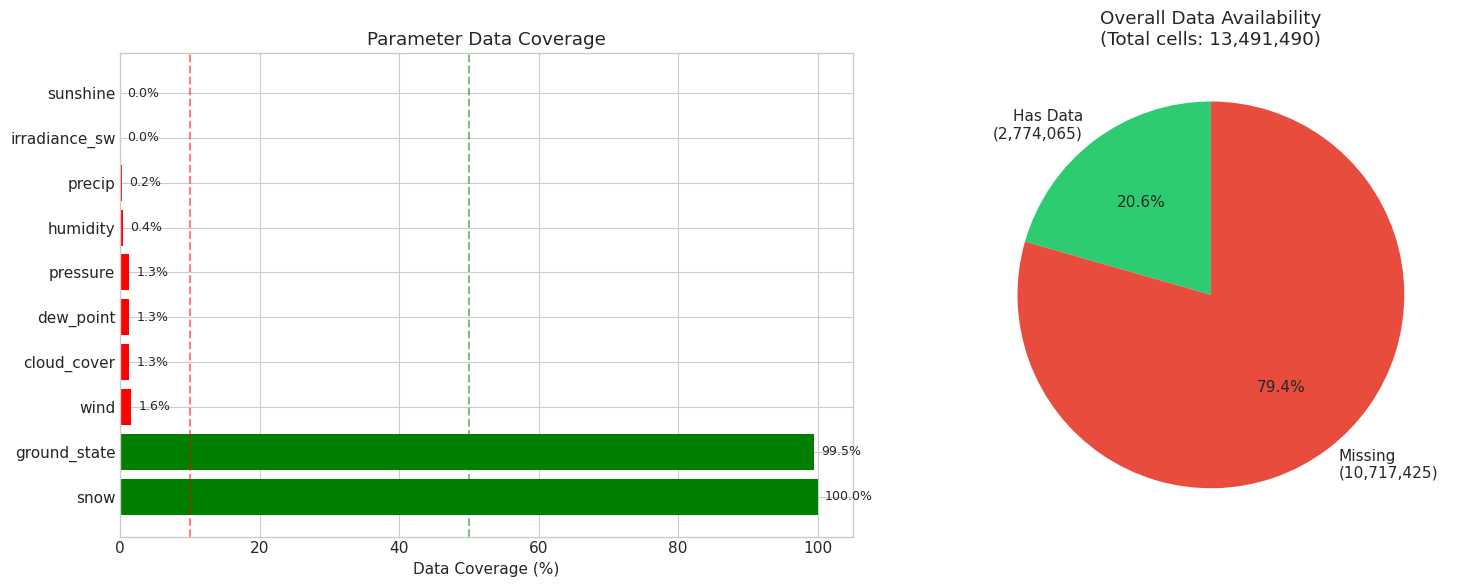

In [8]:
# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of coverage
colors = ['green' if x > 50 else 'orange' if x > 10 else 'red' for x in missing_stats['Coverage %']]
axes[0].barh(missing_stats.index, missing_stats['Coverage %'], color=colors)
axes[0].set_xlabel('Data Coverage (%)')
axes[0].set_title('Parameter Data Coverage')
axes[0].axvline(x=50, color='green', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
for i, (idx, row) in enumerate(missing_stats.iterrows()):
    axes[0].text(row['Coverage %'] + 1, i, f"{row['Coverage %']:.1f}%", va='center', fontsize=9)

# Pie chart of overall data availability
total_cells = len(df) * len(param_cols)
non_null_cells = df[param_cols].notna().sum().sum()
null_cells = total_cells - non_null_cells

axes[1].pie([non_null_cells, null_cells], 
            labels=[f'Has Data\n({non_null_cells:,})', f'Missing\n({null_cells:,})'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title(f'Overall Data Availability\n(Total cells: {total_cells:,})')

plt.tight_layout()
plt.show()

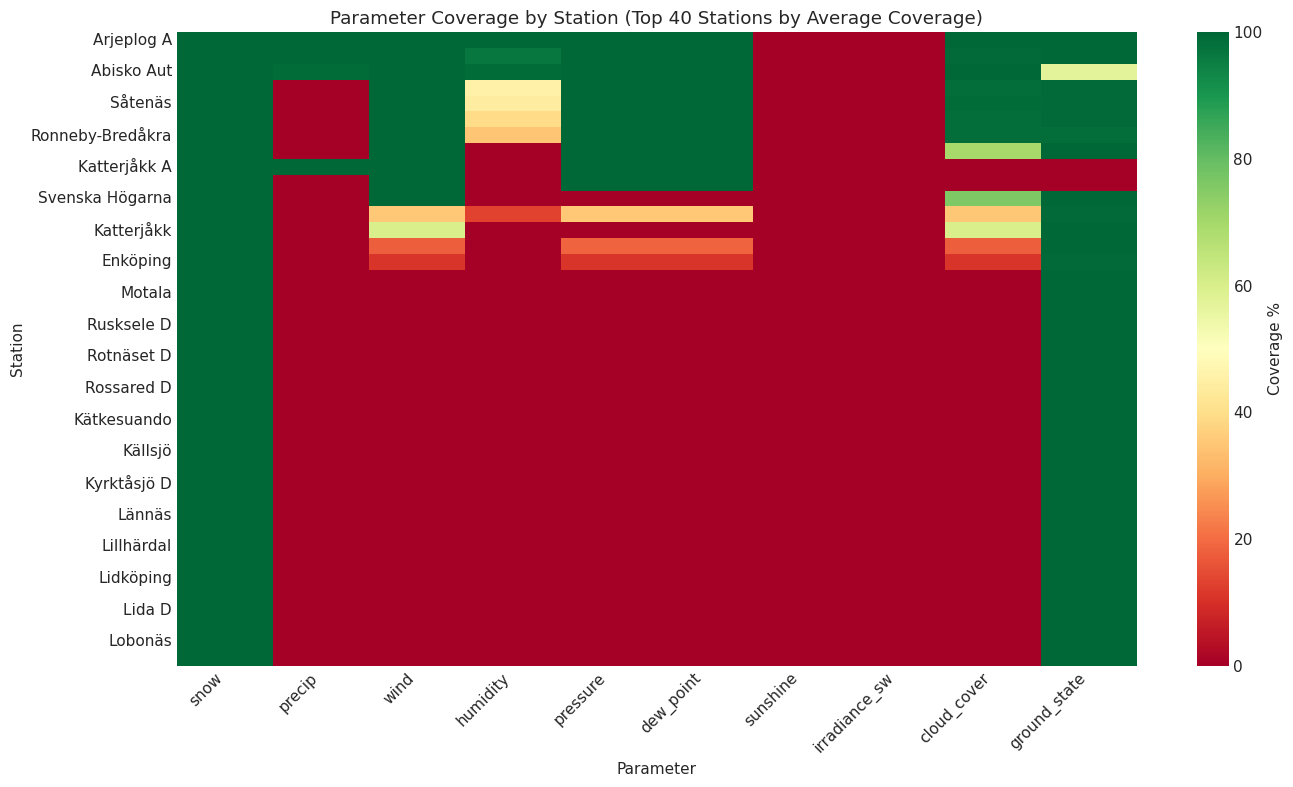

In [9]:
# Heatmap of missing data by parameter
fig, ax = plt.subplots(figsize=(14, 8))

# Sample data for visualization (too many rows for full heatmap)
sample_stations = df['station_name'].unique()[:30]
sample_df = df[df['station_name'].isin(sample_stations)]

# Create pivot table of data availability by station
station_coverage = df.groupby('station_name')[param_cols].apply(lambda x: x.notna().mean() * 100)
station_coverage_sorted = station_coverage.loc[station_coverage.mean(axis=1).sort_values(ascending=False).index]

# Show top 40 stations
sns.heatmap(station_coverage_sorted.head(40), annot=False, cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Coverage %'})
ax.set_title('Parameter Coverage by Station (Top 40 Stations by Average Coverage)')
ax.set_xlabel('Parameter')
ax.set_ylabel('Station')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Check for Zero Values vs Actual Data

In [10]:
# Analyze zero vs non-zero values (excluding NaN)
print("=" * 80)
print("ZERO VALUE ANALYSIS (Are parameters actually zero or missing?)")
print("=" * 80)

for col in param_cols:
    non_null = df[col].notna()
    if non_null.sum() > 0:
        non_null_data = df.loc[non_null, col]
        zero_count = (non_null_data == 0).sum()
        non_zero_count = (non_null_data != 0).sum()
        zero_pct = zero_count / len(non_null_data) * 100
        
        print(f"\n{col}:")
        print(f"  Non-null records: {len(non_null_data):,}")
        print(f"  Zero values: {zero_count:,} ({zero_pct:.1f}%)")
        print(f"  Non-zero values: {non_zero_count:,} ({100-zero_pct:.1f}%)")
        if len(non_null_data) > 0:
            print(f"  Range: [{non_null_data.min():.4f}, {non_null_data.max():.4f}]")
            print(f"  Mean: {non_null_data.mean():.4f}")
    else:
        print(f"\n{col}: NO DATA (all values are NaN)")

ZERO VALUE ANALYSIS (Are parameters actually zero or missing?)

snow:
  Non-null records: 1,349,149
  Zero values: 1,012,708 (75.1%)
  Non-zero values: 336,441 (24.9%)
  Range: [-0.0200, 2.2900]
  Mean: 0.0812

precip:
  Non-null records: 3,422
  Zero values: 1,712 (50.0%)
  Non-zero values: 1,710 (50.0%)
  Range: [0.0000, 76.3000]
  Mean: 1.6112

wind:
  Non-null records: 21,297
  Zero values: 10 (0.0%)
  Non-zero values: 21,287 (100.0%)
  Range: [0.0000, 20.6000]
  Mean: 4.3137

humidity:
  Non-null records: 5,947
  Zero values: 41 (0.7%)
  Non-zero values: 5,906 (99.3%)
  Range: [0.0000, 9.0000]
  Mean: 4.9197

pressure:
  Non-null records: 17,265
  Zero values: 0 (0.0%)
  Non-zero values: 17,265 (100.0%)
  Range: [950.1458, 1053.9000]
  Mean: 1012.3725

dew_point:
  Non-null records: 17,262
  Zero values: 10 (0.1%)
  Non-zero values: 17,252 (99.9%)
  Range: [-34.0833, 20.8600]
  Mean: 2.5667

sunshine: NO DATA (all values are NaN)

irradiance_sw: NO DATA (all values are NaN)

cloud

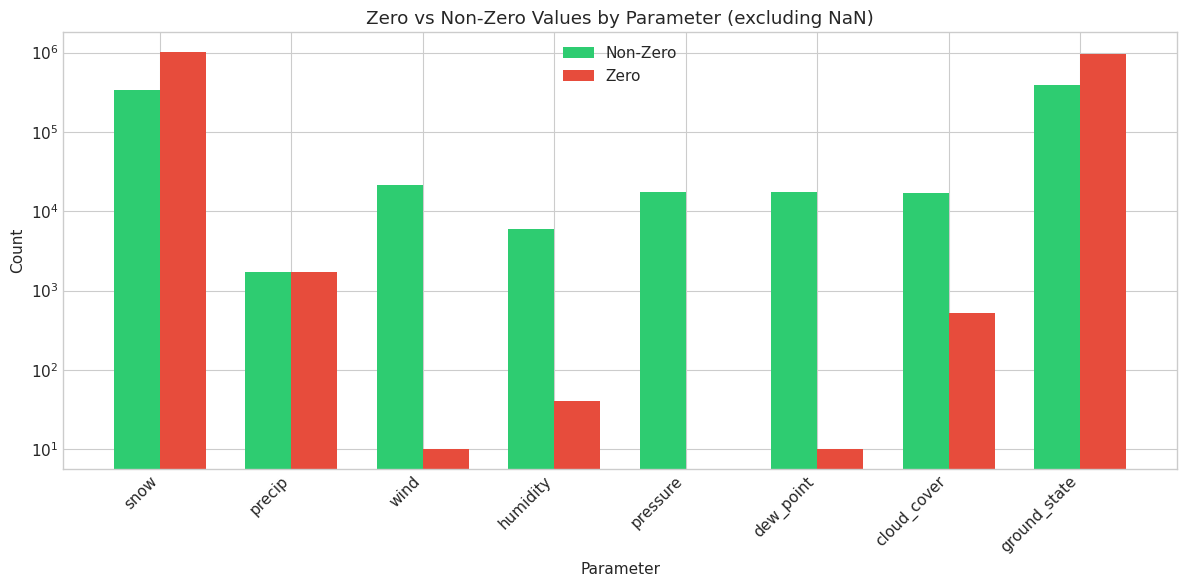

In [11]:
# Visual summary of zero values
zero_analysis = []
for col in param_cols:
    non_null = df[col].notna()
    if non_null.sum() > 0:
        non_null_data = df.loc[non_null, col]
        zero_count = (non_null_data == 0).sum()
        non_zero_count = (non_null_data != 0).sum()
        zero_analysis.append({
            'Parameter': col,
            'Total Records': len(non_null_data),
            'Zero Values': zero_count,
            'Non-Zero Values': non_zero_count,
            'Zero %': zero_count / len(non_null_data) * 100 if len(non_null_data) > 0 else 0
        })

zero_df = pd.DataFrame(zero_analysis)
if len(zero_df) > 0:
    zero_df = zero_df.set_index('Parameter')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(zero_df))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], zero_df['Non-Zero Values'], width, label='Non-Zero', color='#2ecc71')
    bars2 = ax.bar([i + width/2 for i in x], zero_df['Zero Values'], width, label='Zero', color='#e74c3c')
    
    ax.set_xlabel('Parameter')
    ax.set_ylabel('Count')
    ax.set_title('Zero vs Non-Zero Values by Parameter (excluding NaN)')
    ax.set_xticks(x)
    ax.set_xticklabels(zero_df.index, rotation=45, ha='right')
    ax.legend()
    ax.set_yscale('log')  # Log scale for better visibility
    
    plt.tight_layout()
    plt.show()

## 4. Station Analysis

In [12]:
# Station statistics
station_stats = df.groupby(['station_id', 'station_name', 'latitude', 'longitude', 'elevation']).agg({
    'date': ['min', 'max', 'count'],
    'snow': 'count'
}).reset_index()

station_stats.columns = ['station_id', 'station_name', 'latitude', 'longitude', 'elevation', 
                         'first_date', 'last_date', 'total_records', 'snow_records']

print(f"Total Stations: {len(station_stats)}")
print(f"\nStations by record count:")
print(station_stats.sort_values('total_records', ascending=False).head(20))

Total Stations: 605

Stations by record count:
     station_id   station_name  latitude  longitude  elevation first_date  last_date  total_records  snow_records
590      182800   Saittarova D   67.3369    22.2308    238.200 2015-01-01 2023-12-31           3287          3287
526      150530      Kusmark D   64.8836    20.8284     57.718 2015-01-01 2023-12-31           3287          3287
68        65500     Orrefors D   56.8213    15.6982    174.688 2015-01-01 2023-12-31           3287          3287
498      145150    Kyrktåsjö D   64.2454    15.8454    272.209 2015-01-01 2023-12-31           3287          3287
133       75430     Södra Vi D   57.7172    15.7063    173.568 2015-01-01 2023-12-31           3287          3287
447      133190         Mörsil   63.3183    13.6458    420.343 2015-01-01 2023-12-31           3287          3287
570      171990       Sadjem D   66.9602    21.2275    359.074 2015-01-01 2023-12-31           3287          3287
561      167790  Svartberget D   66.3227 

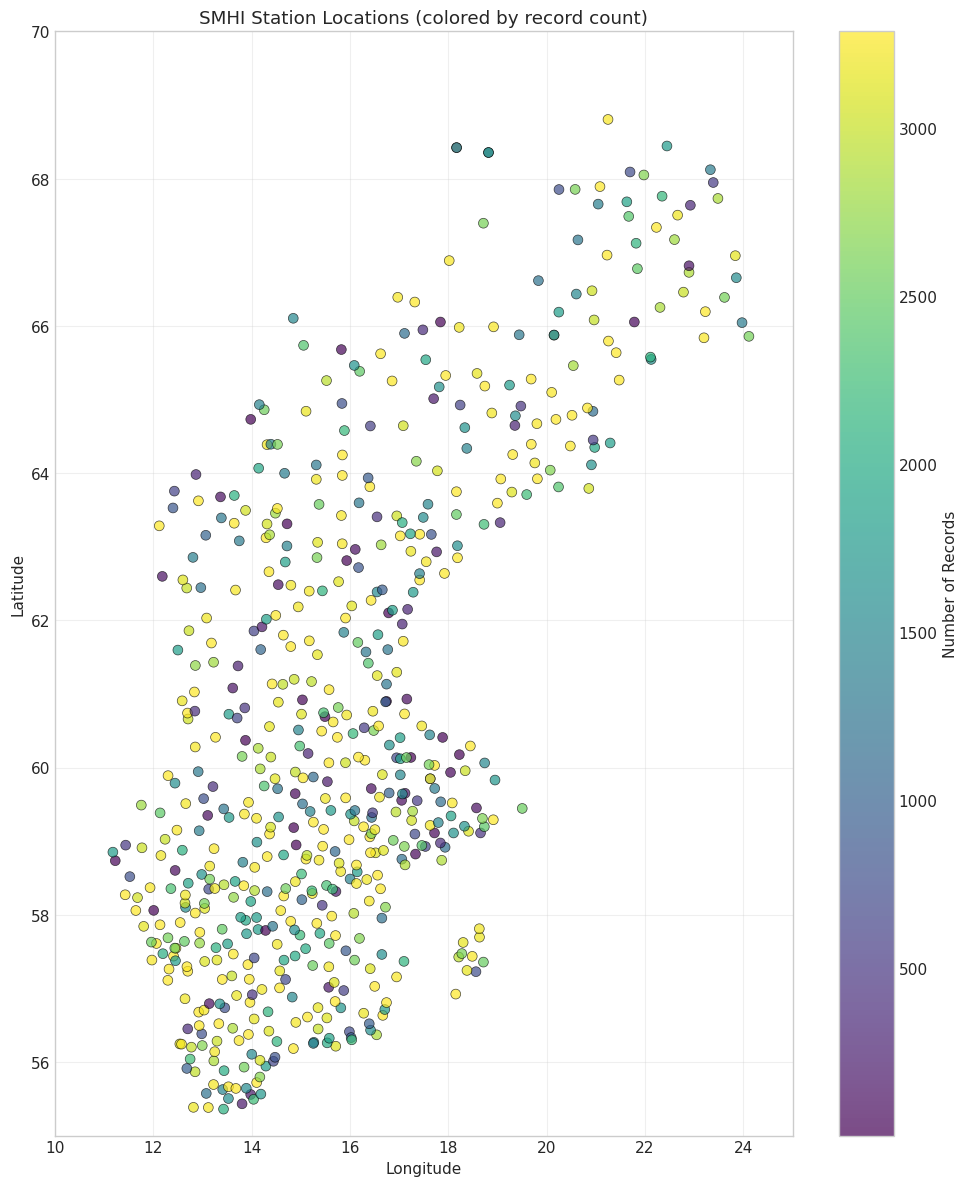

In [13]:
# Map of station locations
fig, ax = plt.subplots(figsize=(10, 12))

# Color by number of records
scatter = ax.scatter(station_stats['longitude'], station_stats['latitude'], 
                     c=station_stats['total_records'], cmap='viridis', 
                     s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, ax=ax, label='Number of Records')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SMHI Station Locations (colored by record count)')
ax.grid(True, alpha=0.3)

# Add Sweden approximate boundary
ax.set_xlim(10, 25)
ax.set_ylim(55, 70)

plt.tight_layout()
plt.show()

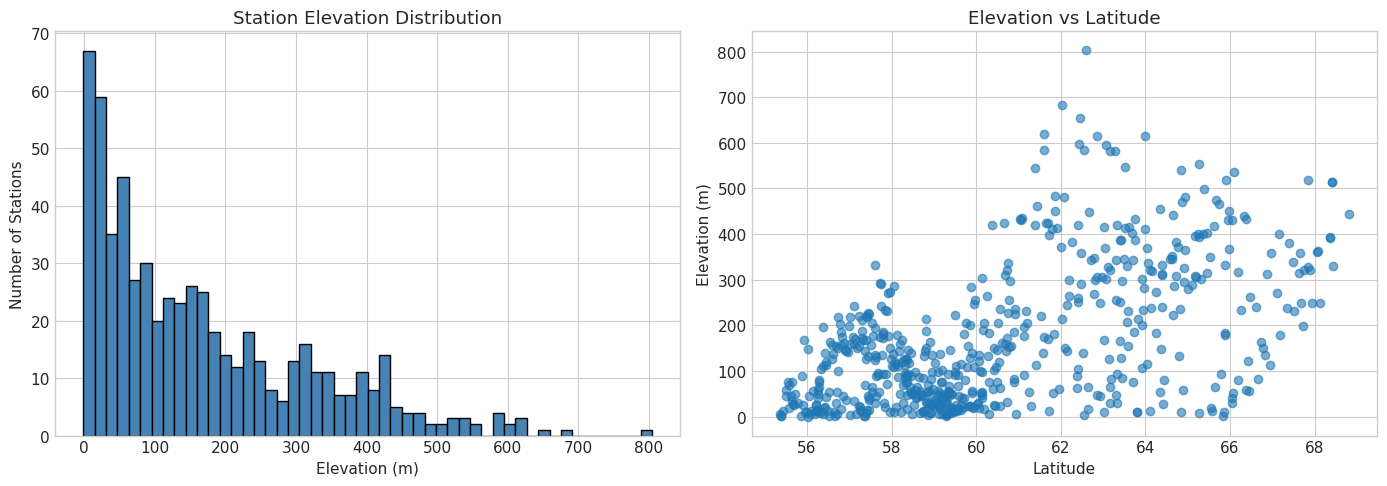

In [14]:
# Elevation distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of elevations
station_stats['elevation'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Number of Stations')
axes[0].set_title('Station Elevation Distribution')

# Elevation vs Latitude
axes[1].scatter(station_stats['latitude'], station_stats['elevation'], alpha=0.6)
axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Elevation (m)')
axes[1].set_title('Elevation vs Latitude')

plt.tight_layout()
plt.show()

## 5. Temporal Analysis

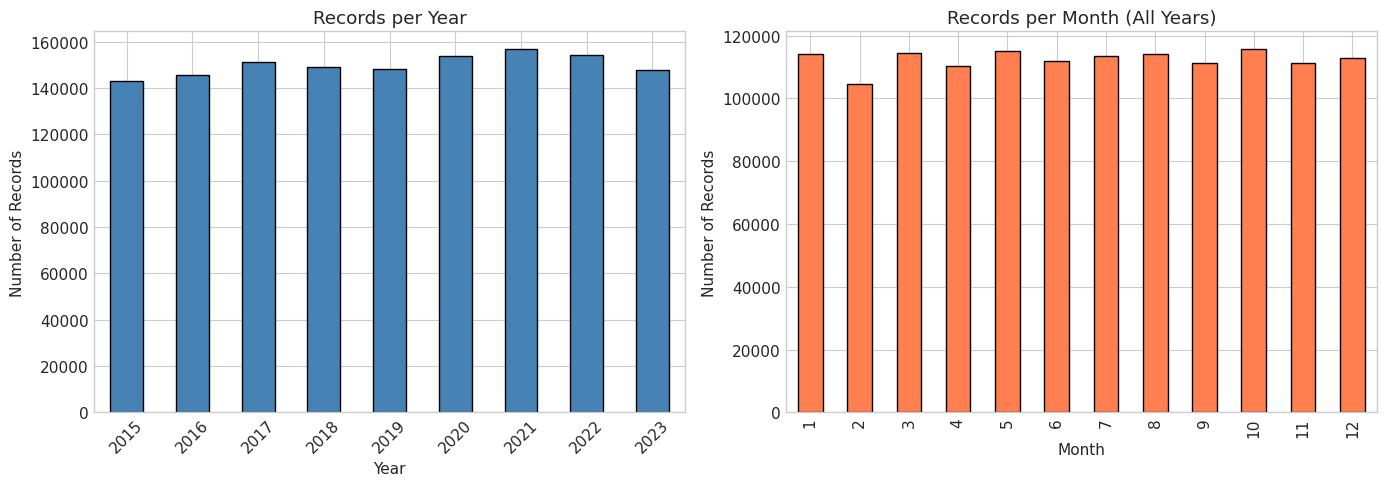

In [15]:
# Add temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

# Records per year
yearly_counts = df.groupby('year').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Records per Year')
axes[0].tick_params(axis='x', rotation=45)

# Records per month
monthly_counts = df.groupby('month').size()
monthly_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Records')
axes[1].set_title('Records per Month (All Years)')

plt.tight_layout()
plt.show()

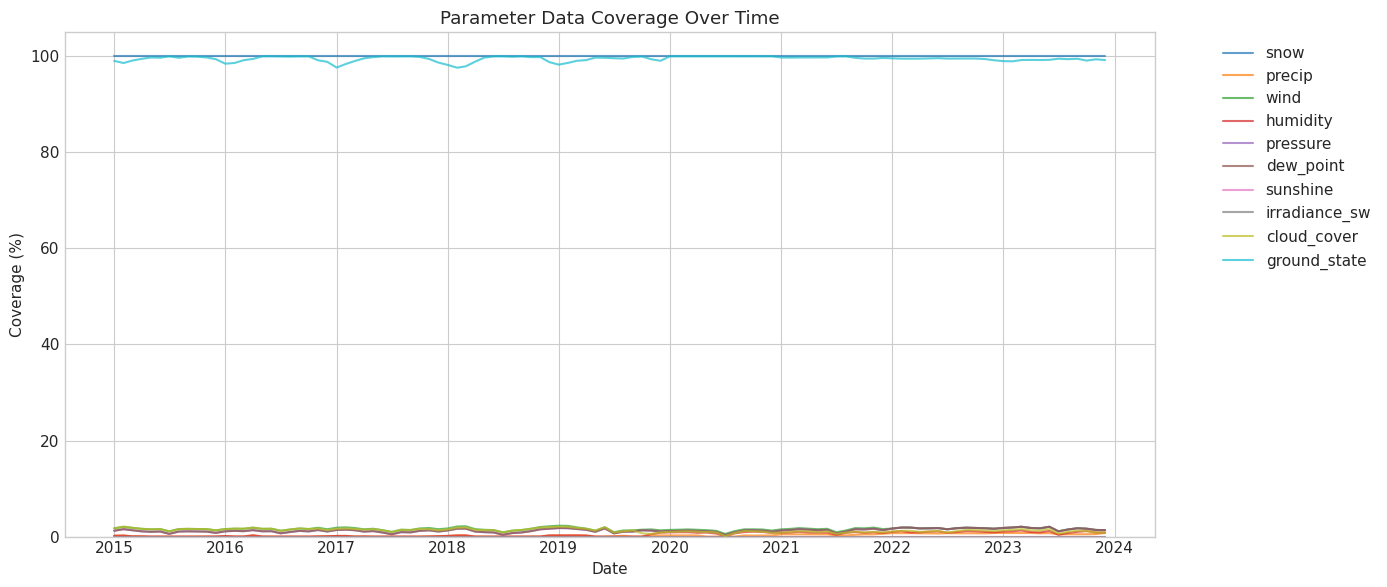

In [16]:
# Data coverage over time for each parameter
fig, ax = plt.subplots(figsize=(14, 6))

for col in param_cols:
    monthly_coverage = df.groupby([df['date'].dt.to_period('M')])[col].apply(lambda x: x.notna().mean() * 100)
    monthly_coverage.index = monthly_coverage.index.to_timestamp()
    ax.plot(monthly_coverage.index, monthly_coverage.values, label=col, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Coverage (%)')
ax.set_title('Parameter Data Coverage Over Time')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 6. Snow Depth Analysis (Primary Target)

In [17]:
# Filter to snow data only
snow_df = df[df['snow'].notna()].copy()
print(f"Records with snow data: {len(snow_df):,} ({len(snow_df)/len(df)*100:.1f}%)")

# Convert snow from meters to cm for easier interpretation
snow_df['snow_cm'] = snow_df['snow'] * 100

print(f"\nSnow Depth Statistics (cm):")
print(snow_df['snow_cm'].describe())

Records with snow data: 1,349,149 (100.0%)

Snow Depth Statistics (cm):
count    1.349149e+06
mean     8.121196e+00
std      2.017793e+01
min     -2.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.290000e+02
Name: snow_cm, dtype: float64


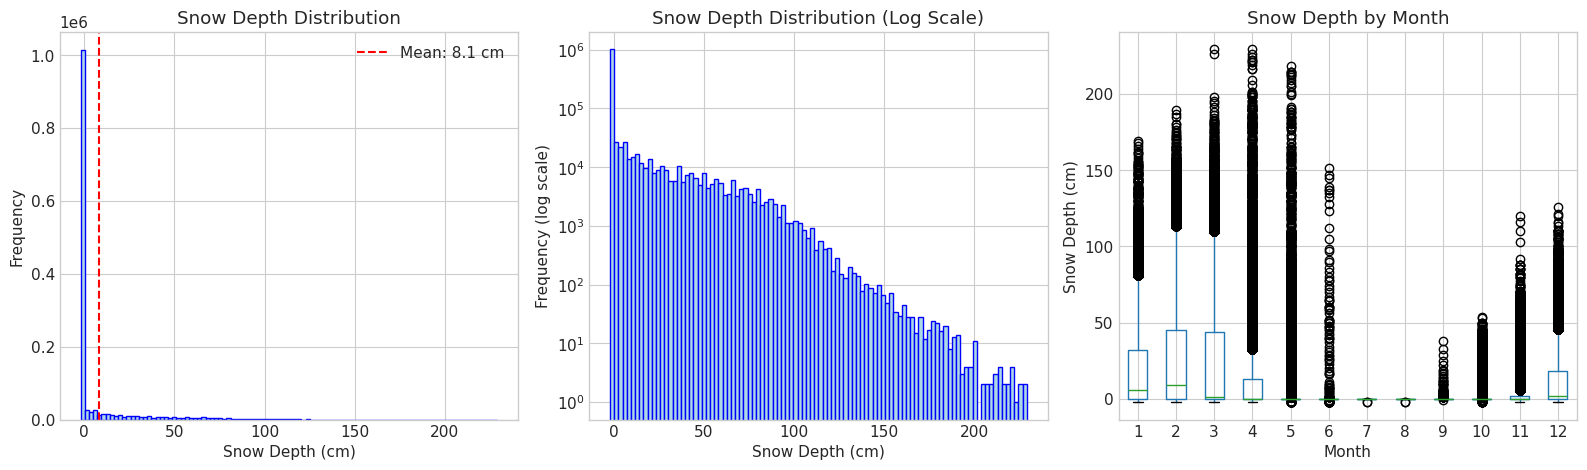

In [18]:
# Snow depth distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
snow_df['snow_cm'].hist(bins=100, ax=axes[0], color='lightblue', edgecolor='blue')
axes[0].set_xlabel('Snow Depth (cm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Snow Depth Distribution')
axes[0].axvline(snow_df['snow_cm'].mean(), color='red', linestyle='--', label=f'Mean: {snow_df["snow_cm"].mean():.1f} cm')
axes[0].legend()

# Log scale histogram (to see rare deep snow events)
snow_df['snow_cm'].hist(bins=100, ax=axes[1], color='lightblue', edgecolor='blue')
axes[1].set_xlabel('Snow Depth (cm)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Snow Depth Distribution (Log Scale)')
axes[1].set_yscale('log')

# Box plot by month
snow_df.boxplot(column='snow_cm', by='month', ax=axes[2])
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Snow Depth (cm)')
axes[2].set_title('Snow Depth by Month')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

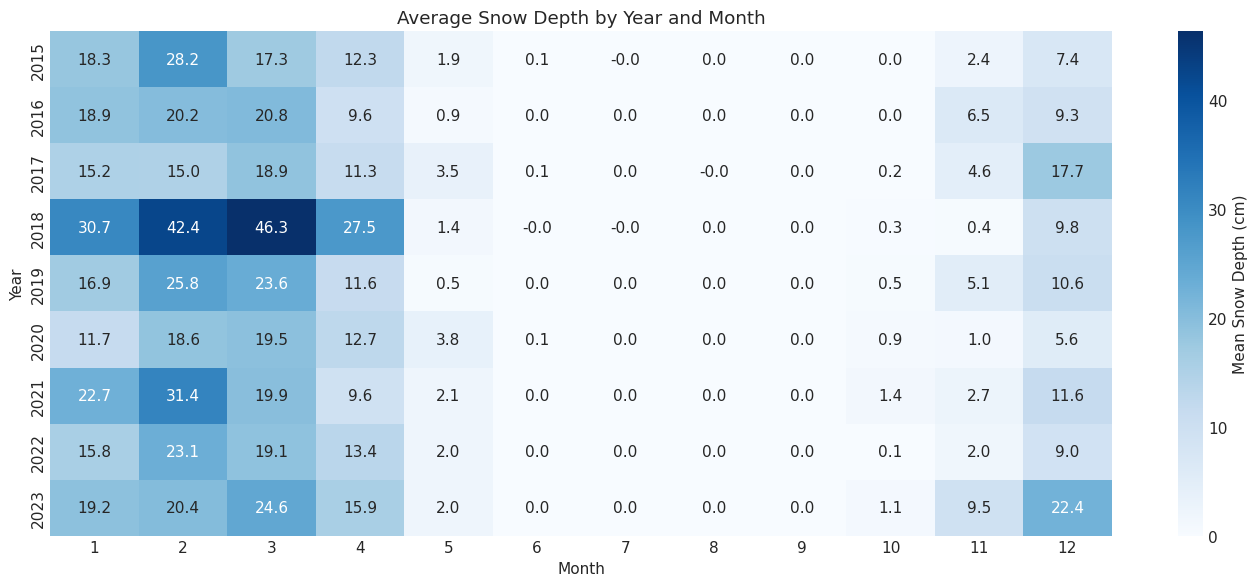

In [19]:
# Average snow depth by month and year
monthly_snow = snow_df.groupby(['year', 'month'])['snow_cm'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(monthly_snow, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar_kws={'label': 'Mean Snow Depth (cm)'})
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title('Average Snow Depth by Year and Month')
plt.tight_layout()
plt.show()

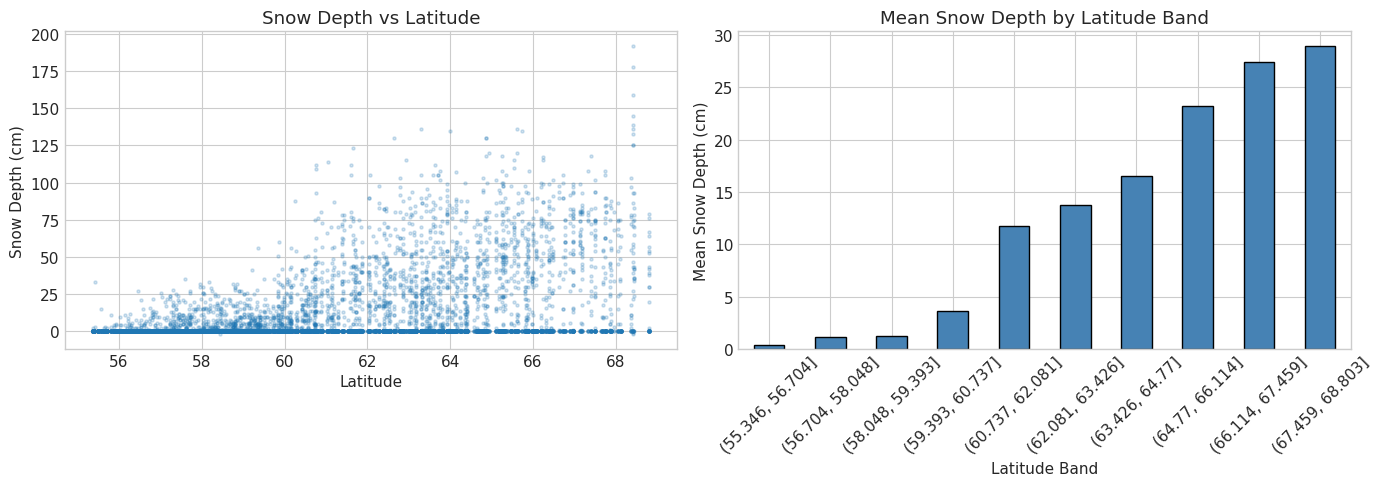

In [20]:
# Snow depth by latitude (north vs south Sweden)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sample = snow_df.sample(min(10000, len(snow_df)))  # Sample for performance
axes[0].scatter(sample['latitude'], sample['snow_cm'], alpha=0.2, s=5)
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Snow Depth (cm)')
axes[0].set_title('Snow Depth vs Latitude')

# Mean snow depth by latitude bands
snow_df['lat_band'] = pd.cut(snow_df['latitude'], bins=10)
lat_snow = snow_df.groupby('lat_band')['snow_cm'].mean()
lat_snow.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Latitude Band')
axes[1].set_ylabel('Mean Snow Depth (cm)')
axes[1].set_title('Mean Snow Depth by Latitude Band')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

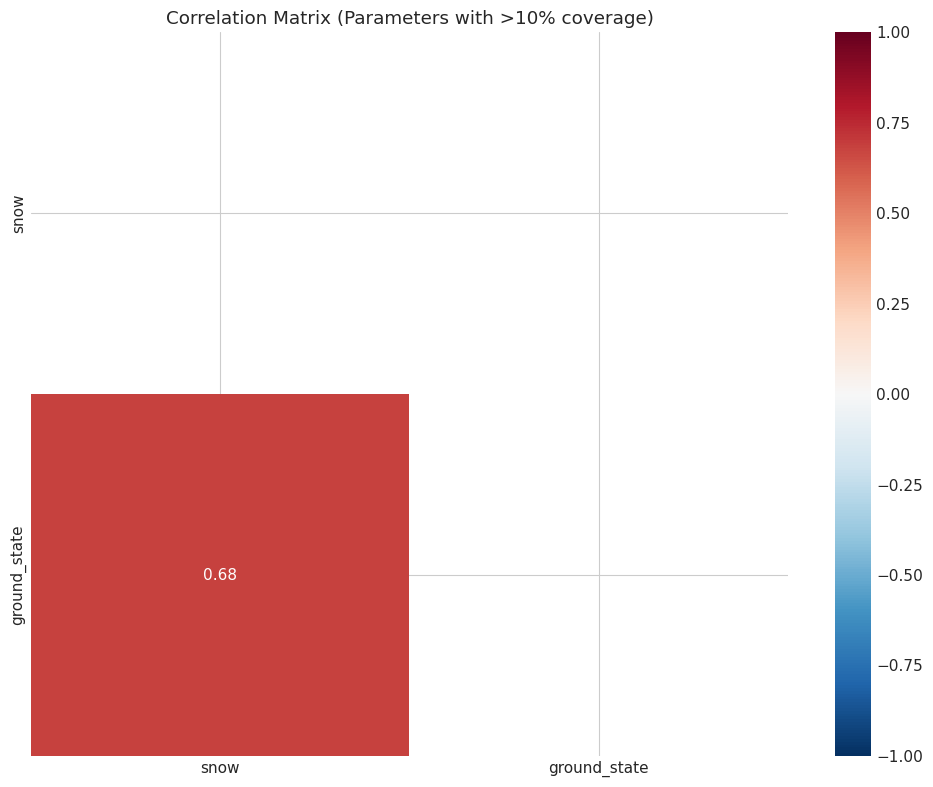

In [21]:
# Correlation matrix for parameters with sufficient data
# Only include columns with > 10% coverage
sufficient_cols = [col for col in param_cols if df[col].notna().mean() > 0.10]

if len(sufficient_cols) > 1:
    corr_matrix = df[sufficient_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix (Parameters with >10% coverage)')
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough parameters with >10% coverage for correlation analysis.")
    print(f"Parameters with sufficient data: {sufficient_cols}")

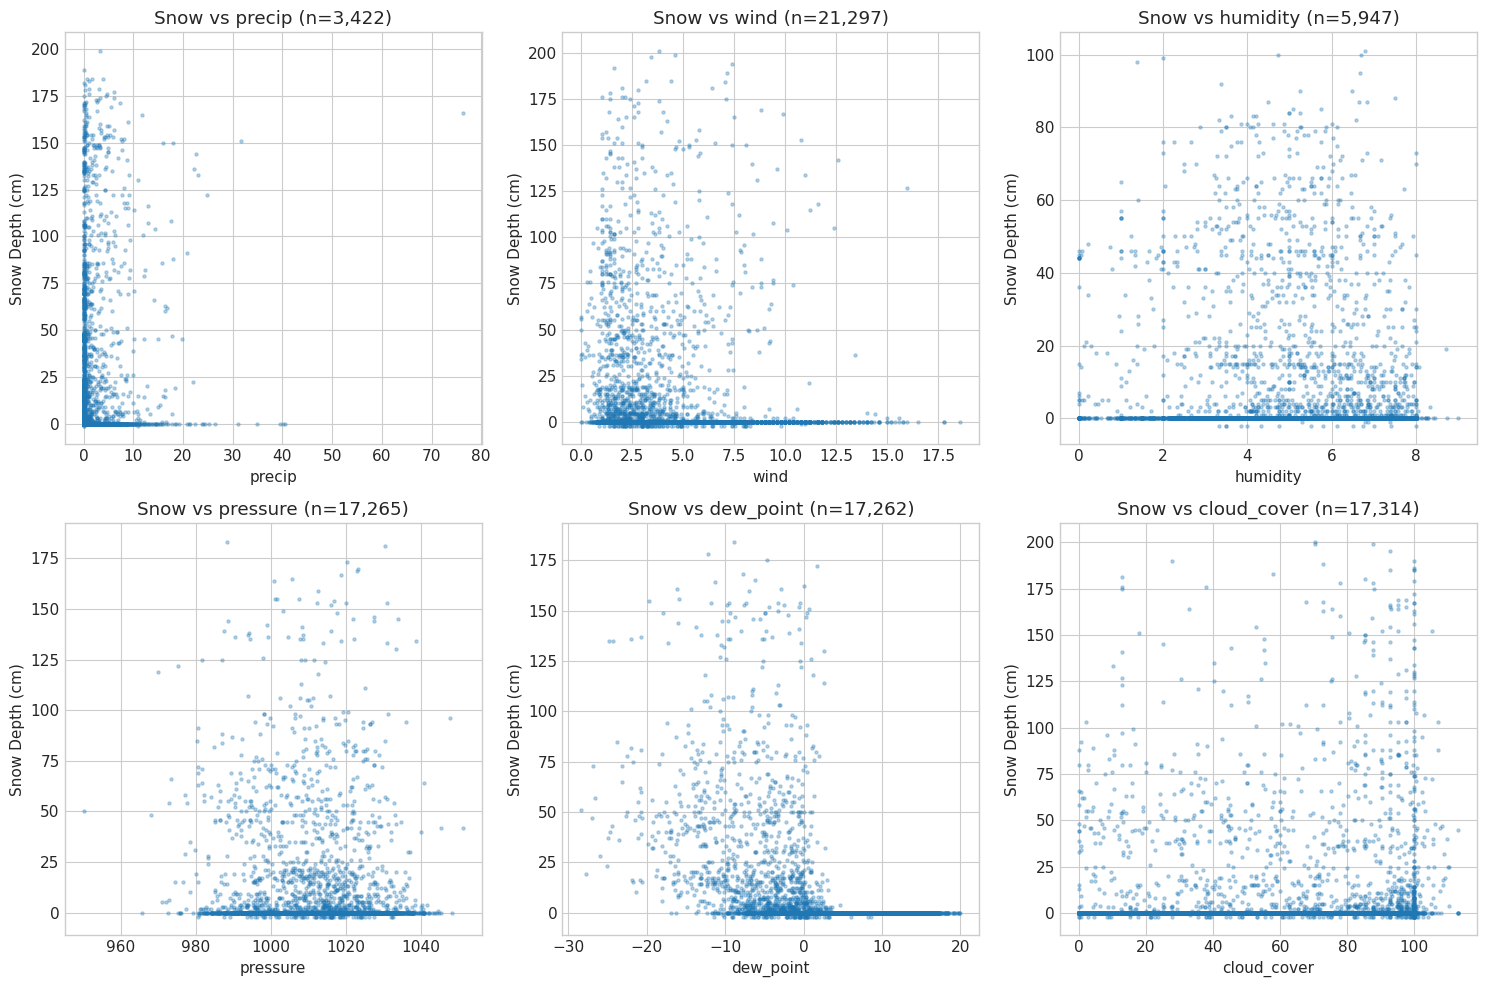

In [22]:
# Pairwise relationships with snow (for columns with data)
cols_with_data = [col for col in param_cols if col != 'snow' and df[col].notna().sum() > 1000]

if len(cols_with_data) > 0:
    n_cols = min(len(cols_with_data), 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(cols_with_data[:6]):
        # Get data where both columns are not null
        mask = df['snow'].notna() & df[col].notna()
        if mask.sum() > 100:
            sample_idx = np.random.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
            axes[i].scatter(df.loc[sample_idx, col], df.loc[sample_idx, 'snow'] * 100, alpha=0.3, s=5)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Snow Depth (cm)')
            axes[i].set_title(f'Snow vs {col} (n={mask.sum():,})')
        else:
            axes[i].text(0.5, 0.5, f'Not enough\noverlapping data\nfor {col}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'Snow vs {col}')
    
    # Hide empty subplots
    for i in range(len(cols_with_data), 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No other parameters have sufficient data for correlation with snow.")

## 8. Anomaly Detection (Extreme Events)

In [23]:
# Identify extreme snow events
if 'snow_cm' not in df.columns:
    df['snow_cm'] = df['snow'] * 100

# Define thresholds for extreme events
snow_99 = df['snow_cm'].quantile(0.99)
snow_95 = df['snow_cm'].quantile(0.95)

print(f"Snow Depth Percentiles:")
print(f"  95th percentile: {snow_95:.1f} cm")
print(f"  99th percentile: {snow_99:.1f} cm")
print(f"  Maximum: {df['snow_cm'].max():.1f} cm")

# Extreme events
extreme_snow = df[df['snow_cm'] > snow_99].copy()
print(f"\nExtreme snow events (>99th percentile): {len(extreme_snow):,}")

Snow Depth Percentiles:
  95th percentile: 58.0 cm
  99th percentile: 92.0 cm
  Maximum: 229.0 cm

Extreme snow events (>99th percentile): 13,215


In [24]:
# Show top extreme events
if len(extreme_snow) > 0:
    print("\nTop 20 Extreme Snow Events:")
    top_events = extreme_snow.nlargest(20, 'snow_cm')[['date', 'station_name', 'latitude', 'longitude', 'elevation', 'snow_cm']]
    display(top_events)


Top 20 Extreme Snow Events:


,date,station_name,latitude,longitude,elevation,snow_cm
467995,2020-03-31,Katterjåkk,68.4207,18.167,513.911,229.0
467996,2020-04-01,Katterjåkk,68.4207,18.167,513.911,229.0
467994,2020-03-30,Katterjåkk,68.4207,18.167,513.911,226.0
467997,2020-04-02,Katterjåkk,68.4207,18.167,513.911,226.0
467998,2020-04-03,Katterjåkk,68.4207,18.167,513.911,224.0
468003,2020-04-15,Katterjåkk,68.4207,18.167,513.911,222.0
468004,2020-04-16,Katterjåkk,68.4207,18.167,513.911,222.0
468002,2020-04-10,Katterjåkk,68.4207,18.167,513.911,221.0
468005,2020-04-17,Katterjåkk,68.4207,18.167,513.911,221.0
468001,2020-04-09,Katterjåkk,68.4207,18.167,513.911,219.0



Records with daily snow change > 20 cm: 2,142


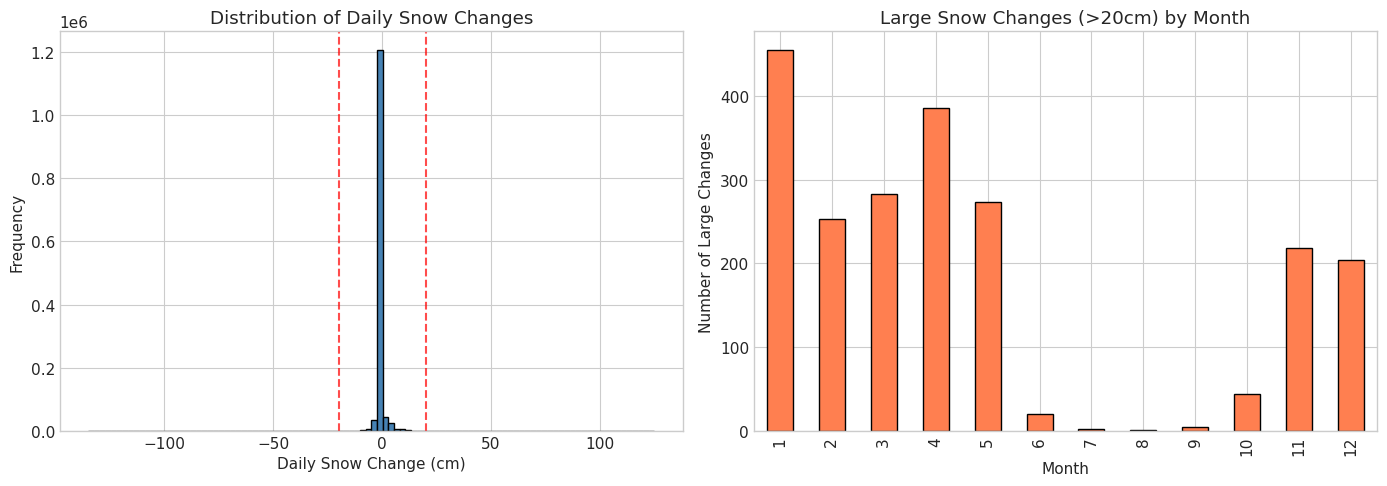

In [25]:
# Daily snow change (potential anomalies)
df_sorted = df.sort_values(['station_id', 'date'])
df_sorted['snow_change'] = df_sorted.groupby('station_id')['snow_cm'].diff()

# Large daily changes
large_changes = df_sorted[abs(df_sorted['snow_change']) > 20].copy()
print(f"\nRecords with daily snow change > 20 cm: {len(large_changes):,}")

if len(large_changes) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of daily changes
    df_sorted['snow_change'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Daily Snow Change (cm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Daily Snow Changes')
    axes[0].axvline(20, color='red', linestyle='--', alpha=0.7)
    axes[0].axvline(-20, color='red', linestyle='--', alpha=0.7)
    
    # Large changes by month
    large_changes['month'] = large_changes['date'].dt.month
    large_changes.groupby('month').size().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of Large Changes')
    axes[1].set_title('Large Snow Changes (>20cm) by Month')
    
    plt.tight_layout()
    plt.show()

## 9. Data Quality Summary

In [26]:
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Total stations: {df['station_id'].nunique()}")
print(f"   - Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   - Parameters: {len(param_cols)}")

print(f"\n2. PARAMETER COVERAGE:")
for col in param_cols:
    coverage = df[col].notna().mean() * 100
    status = "OK" if coverage > 50 else "LOW" if coverage > 10 else "VERY LOW"
    print(f"   - {col}: {coverage:.1f}% [{status}]")

print(f"\n3. KEY FINDINGS:")
high_coverage = [col for col in param_cols if df[col].notna().mean() > 0.5]
low_coverage = [col for col in param_cols if df[col].notna().mean() < 0.1]
print(f"   - Parameters with good coverage (>50%): {high_coverage if high_coverage else 'NONE'}")
print(f"   - Parameters with poor coverage (<10%): {low_coverage if low_coverage else 'NONE'}")

print(f"\n4. RECOMMENDATIONS:")
print(f"   - Focus on parameters with >50% coverage for model training")
print(f"   - Consider downloading parameters separately (different station coverage)")
print(f"   - May need to find stations that have multiple parameters available")

DATA QUALITY SUMMARY

1. DATASET OVERVIEW:
   - Total records: 1,349,149
   - Total stations: 605
   - Date range: 2015-01-01 to 2023-12-31
   - Parameters: 10

2. PARAMETER COVERAGE:
   - snow: 100.0% [OK]
   - precip: 0.3% [VERY LOW]
   - wind: 1.6% [VERY LOW]
   - humidity: 0.4% [VERY LOW]
   - pressure: 1.3% [VERY LOW]
   - dew_point: 1.3% [VERY LOW]
   - sunshine: 0.0% [VERY LOW]
   - irradiance_sw: 0.0% [VERY LOW]
   - cloud_cover: 1.3% [VERY LOW]
   - ground_state: 99.5% [OK]

3. KEY FINDINGS:
   - Parameters with good coverage (>50%): ['snow', 'ground_state']
   - Parameters with poor coverage (<10%): ['precip', 'wind', 'humidity', 'pressure', 'dew_point', 'sunshine', 'irradiance_sw', 'cloud_cover']

4. RECOMMENDATIONS:
   - Focus on parameters with >50% coverage for model training
   - Consider downloading parameters separately (different station coverage)
   - May need to find stations that have multiple parameters available


In [27]:
# Find stations with best multi-parameter coverage
station_param_coverage = df.groupby('station_name')[param_cols].apply(lambda x: x.notna().any()).sum(axis=1)
best_stations = station_param_coverage.sort_values(ascending=False).head(20)

print("\nStations with Most Parameters Available:")
print(best_stations)


Stations with Most Parameters Available:
station_name
Arjeplog A                      8
Abisko Aut                      8
Norrköping-SMHI                 8
Såtenäs                         7
Linköping-Malmslätt             7
Luleå-Kallax Flygplats          7
Vidsel                          7
Ronneby-Bredåkra                7
Enköping                        7
Falsterbo                       7
Stockholm-Observatoriekullen    6
Svenska Högarna                 5
Uppsala Aut                     5
Katterjåkk                      5
Katterjåkk A                    5
Saarikoski D                    2
Sanda                           2
Rossö                           2
Sadjem D                        2
Rörvik D                        2
dtype: int64


In [28]:
# Save summary statistics to CSV
summary_df = pd.DataFrame({
    'Parameter': param_cols,
    'Total_Records': [df[col].notna().sum() for col in param_cols],
    'Coverage_Pct': [df[col].notna().mean() * 100 for col in param_cols],
    'Zero_Count': [(df[col] == 0).sum() for col in param_cols],
    'Min': [df[col].min() for col in param_cols],
    'Max': [df[col].max() for col in param_cols],
    'Mean': [df[col].mean() for col in param_cols],
    'Std': [df[col].std() for col in param_cols],
})

summary_df = summary_df.sort_values('Coverage_Pct', ascending=False)
summary_df.to_csv('../data/raw/smhi_13param_summary.csv', index=False)
print("Summary saved to: ../data/raw/smhi_13param_summary.csv")
print("\n")
display(summary_df)

Summary saved to: ../data/raw/smhi_13param_summary.csv




,Parameter,Total_Records,Coverage_Pct,Zero_Count,Min,Max,Mean,Std
0,snow,1349149,100.000000,1012708,-0.020000,2.29,0.081212,0.201779
9,ground_state,1342409,99.500426,949071,0.000000,19.00,4.522044,7.221561
2,wind,21297,1.578551,10,0.000000,20.60,4.313711,2.779834
8,cloud_cover,17314,1.283327,520,0.000000,113.00,61.031803,31.634942
4,pressure,17265,1.279696,0,950.145833,1053.90,1012.372545,11.732772
5,dew_point,17262,1.279473,10,-34.083333,20.86,2.566671,7.826034
3,humidity,5947,0.440796,41,0.000000,9.00,4.919735,1.761996
1,precip,3422,0.253641,1712,0.000000,76.30,1.611192,3.769530
7,irradiance_sw,0,0.000000,0,NaN,NaN,NaN,NaN
6,sunshine,0,0.000000,0,NaN,NaN,NaN,NaN


## 10. Next Steps

Based on the data exploration:

1. **Data Quality Issues**:
   - Many parameters have low coverage (not all stations measure all parameters)
   - Need to either: (a) use only high-coverage parameters, or (b) download parameters separately and find overlapping stations

2. **For Model Training**:
   - Focus on stations/dates where multiple parameters are available
   - Consider imputation strategies for missing values
   - Snow depth has good coverage and shows clear seasonal patterns

3. **Recommended Actions**:
   - Download parameters separately to maximize coverage
   - Create a merged dataset with only stations having core parameters
   - Implement data preprocessing pipeline to handle missing values